In [1]:
# Cài thư viện cần thiết
!pip install ultralytics -q
import numpy as np
import pandas as pd
import os

# List dataset
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 157.7 kB/s eta 0:00:0000:0100:01
/kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET/TEST/downdog/00000030.jpg
/kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET/TEST/downdog/00000042.jpg
/kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET/TEST/downdog/00000080.jpg
/kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET/TEST/downdog/00000027.jpg
/kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET/TEST/downdog/00000115.jpg
/kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET/TEST/downdog/00000095.jpg
/kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET/TEST/downdog/00000089.jpg
/kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET/TEST/downdog/00000048.jpg
/kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET/TEST/downdog/00000033.jpg
/kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET/TEST/downdog/00000016.jpg
/kaggle/inpu

In [2]:
import os, csv, json, pickle
import numpy as np
from ultralytics import YOLO

# ==========================================
# CẤU HÌNH
# ==========================================
TRAIN_DIR = '/kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET/TRAIN'
TEST_DIR  = '/kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET/TEST'

TRAIN_CSV = '/kaggle/working/train_v2.csv'
TEST_CSV  = '/kaggle/working/test_v2.csv'

LABEL_MAP_PATH = '/kaggle/working/label_map.json'
SCALER_PATH    = '/kaggle/working/scaler.pkl'
MODEL_PATH     = '/kaggle/working/yoga_best_v2.pth'

NUM_AUGMENTATIONS = 5

# YOLOv8 
yolo = YOLO('yolov8s-pose.pt')
print("YOLOv8 ready!")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 ready!


In [3]:
import numpy as np

# ==========================================
# HÀM 1: TÍNH GÓC KHỚP (JOINT ANGLE)
# ==========================================
def calc_angle(p1, p2, p3):
    """Tính góc tại p2 (độ). Trả -1 nếu bất kỳ điểm nào = 0 (không detect)."""
    if np.any(p1 == 0) or np.any(p2 == 0) or np.any(p3 == 0):
        return -1.0
    v1 = p1 - p2
    v2 = p3 - p2
    cos_a = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
    return np.degrees(np.arccos(np.clip(cos_a, -1.0, 1.0)))

def get_max_min_angles(a_left, a_right):
    """Phân nhóm góc Lớn (Duỗi thẳng) và góc Nhỏ (Gập) để trị bất đối xứng"""
    if a_left < 0 and a_right < 0: 
        return -1.0, -1.0
    if a_left < 0: 
        return a_right, -1.0
    if a_right < 0: 
        return a_left, -1.0
    return max(a_left, a_right), min(a_left, a_right)

# ==========================================
# HÀM 2: TRÍCH XUẤT FEATURES — v4 (62 chiều)
# ==========================================
# COCO keypoints: 5=L_sho, 6=R_sho, 7=L_elb, 8=R_elb, 9=L_wri, 10=R_wri
#                11=L_hip,12=R_hip,13=L_kne,14=R_kne,15=L_ank,16=R_ank

# Gộp các khớp trái/phải thành từng cặp để dễ so sánh Max/Min
JOINT_PAIRS = [
    (5, 7, 9, 6, 8, 10),       # Cùi chỏ L & R
    (11, 5, 7, 12, 6, 8),      # Vai L & R
    (5, 11, 13, 6, 12, 14),    # Hông L & R
    (11, 13, 15, 12, 14, 16)   # Đầu gối L & R
]

def extract_features(keypoints):
    """
    Input : (17, 3) — [x, y, conf] từ YOLOv8
    Output: (62,)   — 34 xy norm + 17 conf + 8 angles max/min + 3 spatial signals
    """
    kp_xy   = keypoints[:, :2]
    kp_conf = keypoints[:, 2]

    # 1. Tính tâm vai và tâm hông
    hip_center      = (kp_xy[11] + kp_xy[12]) / 2.0
    shoulder_center = (kp_xy[5]  + kp_xy[6])  / 2.0
    torso_length    = np.linalg.norm(shoulder_center - hip_center)
    
    if torso_length < 1e-5:
        return None

    # ==========================================================
    # 3 TÍN HIỆU HÌNH HỌC KHÔNG GIAN (SPATIAL SIGNALS)
    # ==========================================================
    # Tín hiệu 1: Độ rộng vai chuẩn hóa
    shoulder_width = np.linalg.norm(kp_xy[5] - kp_xy[6])
    norm_shoulder_width = shoulder_width / (torso_length + 1e-8)
    
    # Tín hiệu 2: Góc cột sống tuyệt đối (độ nghiêng thân người)
    dx = shoulder_center[0] - hip_center[0]
    dy = shoulder_center[1] - hip_center[1]
    spine_angle = np.degrees(np.arctan2(dy, dx))
    norm_spine_angle = spine_angle / 180.0
    
    # Tín hiệu 3: Tỉ lệ xương (Lưng / Chân)
    left_leg  = np.linalg.norm(kp_xy[11] - kp_xy[13]) + np.linalg.norm(kp_xy[13] - kp_xy[15])
    right_leg = np.linalg.norm(kp_xy[12] - kp_xy[14]) + np.linalg.norm(kp_xy[14] - kp_xy[16])
    avg_leg_length = (left_leg + right_leg) / 2.0
    bone_ratio = torso_length / (avg_leg_length + 1e-8)
    
    spatial_features = np.array([norm_shoulder_width, norm_spine_angle, bone_ratio])
    # ==========================================================

    norm_xy    = (kp_xy - hip_center) / torso_length         # (17,2)
    conf_feat  = np.clip(kp_conf, 0.0, 1.0)                  # (17,)
    
    angle_feat = []
    for i_L, j_L, k_L, i_R, j_R, k_R in JOINT_PAIRS:
        deg_L = calc_angle(kp_xy[i_L], kp_xy[j_L], kp_xy[k_L])
        deg_R = calc_angle(kp_xy[i_R], kp_xy[j_R], kp_xy[k_R])
        
        a_max, a_min = get_max_min_angles(deg_L, deg_R)
        
        angle_feat.append(a_max / 180.0 if a_max >= 0 else -1.0)
        angle_feat.append(a_min / 180.0 if a_min >= 0 else -1.0)

    # Nối toàn bộ lại thành vector 62 chiều
    return np.concatenate([
        norm_xy.flatten(), 
        conf_feat, 
        np.array(angle_feat), 
        spatial_features
    ])


# ==========================================
# HÀM 3: AUGMENTATION
# ==========================================
KP_SWAP_PAIRS    = [(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]

def aug_gaussian(feat, n=5, std=0.02):
    out = []
    for _ in range(n):
        f = feat.copy()
        f[:34] += np.random.normal(0, std, 34)
        out.append(f)
    return out

def aug_flip(feat):
    f = feat.copy()
    xy = f[:34].reshape(17, 2)
    conf = f[34:51].copy()
    
    # Lật theo trục X (tọa độ hình)
    xy[:, 0] *= -1
    for l, r in KP_SWAP_PAIRS: 
        xy[[l,r]] = xy[[r,l]]
        conf[[l,r]] = conf[[r,l]]
    
    f[:34] = xy.flatten()
    f[34:51] = conf

    # Xử lý lật góc cột sống (tín hiệu không gian nằm ở index 60)
    spine_deg = f[60] * 180.0
    new_spine = 180.0 - spine_deg
    if new_spine > 180.0: new_spine -= 360.0
    f[60] = new_spine / 180.0
    
    return [f]

def aug_scale(feat, n=2, scale_range=(0.85, 1.15)):
    out = []
    for _ in range(n):
        f = feat.copy()
        f[:34] *= np.random.uniform(*scale_range)
        out.append(f)
    return out

def aug_rotate(feat, n=2, angle_range=(-20, 20)):
    out = []
    for _ in range(n):
        f = feat.copy()
        xy = f[:34].reshape(17, 2)
        theta = np.radians(np.random.uniform(*angle_range))
        R = np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])
        f[:34] = (R @ xy.T).T.flatten()
        out.append(f)
    return out

def augment_all(feat):
    return aug_gaussian(feat,n=5) + aug_flip(feat) + aug_scale(feat,n=2) + aug_rotate(feat,n=2)

feat_test = extract_features(np.random.rand(17,3))
print(f"Feature shape: {feat_test.shape}  (62d: 34 xy + 17 conf + 8 angles + 3 spatial)")
print(f"Aug/ảnh: 1 gốc + {len(augment_all(feat_test))} aug = {1+len(augment_all(feat_test))}x")

Feature shape: (62,)  (62d: 34 xy + 17 conf + 8 angles + 3 spatial)
Aug/ảnh: 1 gốc + 10 aug = 11x


In [4]:
import csv
import os

# ==========================================
# VÒNG LẶP XỬ LÝ DATASET
# ==========================================
N_FEAT = 62

def process_dataset(data_dir, output_csv, is_train_set=True):
    xy_cols   = [f'{ax}{i}' for i in range(17) for ax in ('x','y')]
    conf_cols = [f'conf{i}' for i in range(17)]
    
    ang_cols  = ['ang_elbow_max','ang_elbow_min','ang_shoulder_max','ang_shoulder_min',
                 'ang_hip_max','ang_hip_min','ang_knee_max','ang_knee_min']
    spatial_cols = ['norm_shoulder_width', 'spine_angle', 'bone_ratio']

    headers = ['label'] + xy_cols + conf_cols + ang_cols + spatial_cols

    with open(output_csv, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(headers)

        for pose_name in sorted(os.listdir(data_dir)):
            pose_folder = os.path.join(data_dir, pose_name)
            if not os.path.isdir(pose_folder):
                continue

            print(f"Pose_name: {pose_name}")
            n_orig = n_total = 0

            for img_name in os.listdir(pose_folder):
                if not img_name.lower().endswith(('.jpg','.jpeg','.png','.webp')):
                    continue

                try:
                    results = yolo(os.path.join(pose_folder, img_name), verbose=False)
                    if not results or results[0].keypoints is None or len(results[0].keypoints) == 0:
                        continue

                    raw_kpts = results[0].keypoints.data[0].cpu().numpy()  # (17,3)
                    feat = extract_features(raw_kpts)
                    if feat is None:
                        continue

                    # Ghi ảnh gốc
                    writer.writerow([pose_name] + feat.tolist())
                    n_orig  += 1
                    n_total += 1

                    # Augmentation chỉ trên tập train
                    if is_train_set:
                        for aug in augment_all(feat):
                            writer.writerow([pose_name] + aug.tolist())
                            n_total += 1

                except Exception as e:
                    pass # Đã bỏ in lỗi chi tiết để terminal đỡ bị trôi

            ratio = n_total // n_orig if n_orig else 0
            print(f"{n_orig} ảnh gốc × {ratio} = {n_total} dòng")

# Chạy xử lý dữ liệu
process_dataset(TRAIN_DIR, TRAIN_CSV, is_train_set=True)
process_dataset(TEST_DIR,  TEST_CSV,  is_train_set=False)

print("Tổng dòng train:", end=" ")
import subprocess
result = subprocess.run(['wc','-l', TRAIN_CSV], capture_output=True, text=True)
print(result.stdout.strip())

Pose_name: downdog
205 ảnh gốc × 11 = 2255 dòng
Pose_name: goddess


Corrupt JPEG data: premature end of data segment


174 ảnh gốc × 11 = 1914 dòng
Pose_name: plank
263 ảnh gốc × 11 = 2893 dòng
Pose_name: tree
WARNING ⚠️ Image Read Error /kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET/TRAIN/tree/00000114.jpg
154 ảnh gốc × 11 = 1694 dòng
Pose_name: warrior2
251 ảnh gốc × 11 = 2761 dòng
Pose_name: downdog
94 ảnh gốc × 1 = 94 dòng
Pose_name: goddess
80 ảnh gốc × 1 = 80 dòng
Pose_name: plank
115 ảnh gốc × 1 = 115 dòng
Pose_name: tree
68 ảnh gốc × 1 = 68 dòng
Pose_name: warrior2
107 ảnh gốc × 1 = 107 dòng
Tổng dòng train: 11518 /kaggle/working/train_v2.csv


In [5]:
# ==========================================
# TÍNH POSE STATS — PHÂN PHỐI GÓC & KHÔNG GIAN
# ==========================================
import json
import numpy as np
import os

ANG_COLS = ['ang_elbow_max','ang_elbow_min','ang_shoulder_max','ang_shoulder_min',
            'ang_hip_max','ang_hip_min','ang_knee_max','ang_knee_min']

# THÊM MỚI: Các cột không gian
SPATIAL_COLS = ['norm_shoulder_width', 'spine_angle', 'bone_ratio']

# Gom thành các cặp Trái/Phải để gộp tính Max/Min
ANG_PAIRS_NAMED = [
    (5,  7,  9,  6,  8, 10, 'ang_elbow'),
    (11, 5,  7, 12,  6,  8, 'ang_shoulder'),
    (5, 11, 13,  6, 12, 14, 'ang_hip'),
    (11, 13, 15, 12, 14, 16, 'ang_knee')
]

def calc_angle_raw(p1, p2, p3):
    if np.any(p1 == 0) or np.any(p2 == 0) or np.any(p3 == 0):
        return -1.0
    v1 = p1 - p2
    v2 = p3 - p2
    cos_a = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
    return float(np.degrees(np.arccos(np.clip(cos_a, -1.0, 1.0))))

def get_max_min_angles(a_left, a_right):
    if a_left < 0 and a_right < 0: return -1.0, -1.0
    if a_left < 0: return a_right, -1.0
    if a_right < 0: return a_left, -1.0
    return max(a_left, a_right), min(a_left, a_right)

pose_stats = {}
CONF_MIN_STATS = 0.3

for pose_name in sorted(os.listdir(TRAIN_DIR)):
    pose_folder = os.path.join(TRAIN_DIR, pose_name)
    if not os.path.isdir(pose_folder):
        continue

    # Khởi tạo bucket cho cả Góc khớp và Không gian
    feature_buckets = {col: [] for col in ANG_COLS + SPATIAL_COLS}

    for img_name in os.listdir(pose_folder):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
            continue
        img_path = os.path.join(pose_folder, img_name)
        try:
            results = yolo(img_path, verbose=False)
            if not results or results[0].keypoints is None or len(results[0].keypoints) == 0:
                continue
            
            raw_kpts = results[0].keypoints.data[0].cpu().numpy()  # (17, 3)
            kp_xy   = raw_kpts[:, :2]
            kp_conf = raw_kpts[:, 2]

            # 1. Tính toán các góc khớp (như cũ)
            for i_L, j_L, k_L, i_R, j_R, k_R, name in ANG_PAIRS_NAMED:
                if kp_conf[i_L] < CONF_MIN_STATS or kp_conf[j_L] < CONF_MIN_STATS or kp_conf[k_L] < CONF_MIN_STATS:
                    deg_L = -1.0
                else:
                    deg_L = calc_angle_raw(kp_xy[i_L], kp_xy[j_L], kp_xy[k_L])
                
                if kp_conf[i_R] < CONF_MIN_STATS or kp_conf[j_R] < CONF_MIN_STATS or kp_conf[k_R] < CONF_MIN_STATS:
                    deg_R = -1.0
                else:
                    deg_R = calc_angle_raw(kp_xy[i_R], kp_xy[j_R], kp_xy[k_R])
                
                a_max, a_min = get_max_min_angles(deg_L, deg_R)
                
                if a_max >= 0: feature_buckets[f"{name}_max"].append(a_max)
                if a_min >= 0: feature_buckets[f"{name}_min"].append(a_min)

            # 2. TÍNH TOÁN CÁC ĐẶC TRƯNG KHÔNG GIAN
            if (kp_conf[5] >= CONF_MIN_STATS and kp_conf[6] >= CONF_MIN_STATS and 
                kp_conf[11] >= CONF_MIN_STATS and kp_conf[12] >= CONF_MIN_STATS):
                
                hip_c = (kp_xy[11] + kp_xy[12]) / 2.0
                sho_c = (kp_xy[5]  + kp_xy[6])  / 2.0
                torso_length = np.linalg.norm(sho_c - hip_c)

                if torso_length > 1e-5:
                    # Tín hiệu 1: Độ rộng vai chuẩn hóa
                    shoulder_width = np.linalg.norm(kp_xy[5] - kp_xy[6])
                    feature_buckets['norm_shoulder_width'].append(shoulder_width / torso_length)

                    # Tín hiệu 2: Góc cột sống tuyệt đối (độ)
                    dx = sho_c[0] - hip_c[0]
                    dy = sho_c[1] - hip_c[1]
                    spine_angle = np.degrees(np.arctan2(dy, dx))
                    feature_buckets['spine_angle'].append(spine_angle)

                    # Tín hiệu 3: Tỉ lệ xương (kiểm tra thêm khớp gối và cổ chân)
                    if (kp_conf[13] >= CONF_MIN_STATS and kp_conf[15] >= CONF_MIN_STATS and 
                        kp_conf[14] >= CONF_MIN_STATS and kp_conf[16] >= CONF_MIN_STATS):
                        left_leg  = np.linalg.norm(kp_xy[11] - kp_xy[13]) + np.linalg.norm(kp_xy[13] - kp_xy[15])
                        right_leg = np.linalg.norm(kp_xy[12] - kp_xy[14]) + np.linalg.norm(kp_xy[14] - kp_xy[16])
                        avg_leg_length = (left_leg + right_leg) / 2.0
                        feature_buckets['bone_ratio'].append(torso_length / (avg_leg_length + 1e-8))

        except Exception:
            continue

    pose_stats[pose_name] = {}
    for col, vals in feature_buckets.items():
        if len(vals) < 5:
            pose_stats[pose_name][col] = None
            continue
        vals = np.array(vals)
        pose_stats[pose_name][col] = {
            'mean': float(np.mean(vals)),
            'std':  float(np.std(vals)),
            'p10':  float(np.percentile(vals, 10)),
            'p90':  float(np.percentile(vals, 90)),
            'n':    int(len(vals)),
        }

POSE_STATS_PATH = '/kaggle/working/pose_stats.json'
with open(POSE_STATS_PATH, 'w') as f:
    json.dump(pose_stats, f, indent=2)

print("POSE STATS — Thống kê Đặc trưng (Góc & Không gian)")
print("=" * 65)
for pose, features in pose_stats.items():
    print(f"\n{pose.upper()}")
    for feature_name, s in features.items():
        if s is None:
            print(f"  {feature_name:<22}  (không đủ data)")
        else:
            # Tùy chỉnh đơn vị hiển thị (Độ hoặc Tỷ lệ)
            unit = "°" if "ang" in feature_name or "spine" in feature_name else ""
            print(f"  {feature_name:<22}  {s['mean']:6.2f}{unit} ± {s['std']:5.2f}{unit}"
                  f"  [{s['p10']:.2f}{unit}–{s['p90']:.2f}{unit}]  n={s['n']}")

print(f"\nĐã lưu → {POSE_STATS_PATH}")

Corrupt JPEG data: premature end of data segment


WARNING ⚠️ Image Read Error /kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET/TRAIN/tree/00000114.jpg
POSE STATS — Thống kê Đặc trưng (Góc & Không gian)

DOWNDOG
  ang_elbow_max           166.01° ± 13.87°  [146.99°–178.56°]  n=169
  ang_elbow_min           149.31° ± 24.30°  [120.08°–171.25°]  n=143
  ang_shoulder_max        143.93° ± 44.97°  [64.25°–176.87°]  n=175
  ang_shoulder_min        128.64° ± 47.03°  [51.63°–169.86°]  n=151
  ang_hip_max             116.70° ± 42.57°  [57.62°–171.29°]  n=183
  ang_hip_min             100.13° ± 43.70°  [33.03°–154.12°]  n=163
  ang_knee_max            136.60° ± 40.30°  [73.91°–176.40°]  n=193
  ang_knee_min            114.90° ± 51.68°  [34.72°–169.95°]  n=185
  norm_shoulder_width       0.44 ±  0.78  [0.08–0.79]  n=163
  spine_angle              69.13° ± 88.63°  [-86.72°–154.51°]  n=163
  bone_ratio                0.56 ±  0.27  [0.24–0.84]  n=154

GODDESS
  ang_elbow_max           121.99° ± 40.59°  [59.20°–173.35°]  n=172
  ang_elbo

In [6]:
# ==========================================
# LỌC NGOẠI LAI (Ouliers)
# Tầng 1: Keypoint quality (YOLOv8 detect sai)
# Tầng 2: Statistical outlier (IQR per pose per feature)
# Chạy SAU cell pose_stats, TRƯỚC cell training.
# Output: train_v2_clean.csv
# ==========================================
import pandas as pd
import numpy as np
import json, os

TRAIN_CSV_CLEAN = '/kaggle/working/train_v2_clean.csv'
REPORT_PATH     = '/kaggle/working/outlier_report.json'

# ── Tải lại pose_stats vừa tính ──
with open(POSE_STATS_PATH) as f:
    pose_stats = json.load(f)

df = pd.read_csv(TRAIN_CSV)
n_before = len(df)
print(f"Trước lọc: {n_before:,} dòng\n")

report = {}

# ════════════════════════════════════════
# TẦNG 1 — KEYPOINT QUALITY FILTER
# ════════════════════════════════════════
CONF_COLS    = [f'conf{i}' for i in range(17)]
ANG_COLS     = ['ang_elbow_max','ang_elbow_min','ang_shoulder_max','ang_shoulder_min',
                'ang_hip_max','ang_hip_min','ang_knee_max','ang_knee_min']

# THÊM MỚI: Cột đặc trưng không gian
SPATIAL_COLS = ['norm_shoulder_width', 'spine_angle', 'bone_ratio']

# Các keypoint quan trọng nhất cho yoga (bỏ qua mắt, tai)
CORE_KP = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]  # vai→cổ chân
CORE_CONF_COLS = [f'conf{i}' for i in CORE_KP]

# Tiêu chí lọc keypoint:
CONF_THRESH   = 0.3
MIN_GOOD_KP   = 8   # / 12 core keypoints
MAX_BAD_ANGLES = 4  # / 8 angles

mask_kp_good = (
    (df[CORE_CONF_COLS] >= CONF_THRESH).sum(axis=1) >= MIN_GOOD_KP
)
mask_angle_ok = (
    (df[ANG_COLS] < 0).sum(axis=1) <= MAX_BAD_ANGLES
)
mask_t1 = mask_kp_good & mask_angle_ok

n_t1_removed = (~mask_t1).sum()
report['tier1_keypoint'] = {
    'removed': int(n_t1_removed),
    'pct': round(n_t1_removed / n_before * 100, 1),
    'reason': f'conf<{CONF_THRESH} trên >{12-MIN_GOOD_KP} core keypoints hoặc >{MAX_BAD_ANGLES} angles=-1',
}
print(f"[Tầng 1 - Keypoint quality]")
print(f"  Bỏ: {n_t1_removed:,} dòng ({report['tier1_keypoint']['pct']}%)")
per_pose_t1 = (~mask_t1).groupby(df['label']).sum()
for pose, cnt in per_pose_t1.items():
    print(f"    {pose:<12} {cnt:4d} dòng")

df_t1 = df[mask_t1].copy()
print(f"  Còn lại: {len(df_t1):,} dòng\n")


# ════════════════════════════════════════
# TẦNG 2 — STATISTICAL OUTLIER (IQR)
# ════════════════════════════════════════
IQR_FACTOR    = 3.0
XY_COLS       = [f'{ax}{i}' for i in range(17) for ax in ('x','y')]

# CẬP NHẬT: Quét cả tọa độ, góc khớp và các tín hiệu không gian (34 + 8 + 3 = 45 cols)
FEATURE_COLS  = XY_COLS + ANG_COLS + SPATIAL_COLS

# Tính bounds per-pose
bounds = {}
for pose_name, group in df_t1.groupby('label'):
    bounds[pose_name] = {}
    for col in FEATURE_COLS:
        vals = group[col].replace(-1, np.nan).dropna()
        if len(vals) < 10:
            continue
        q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
        iqr = q3 - q1
        bounds[pose_name][col] = {
            'lo': q1 - IQR_FACTOR * iqr,
            'hi': q3 + IQR_FACTOR * iqr,
        }

# Đánh dấu dòng outlier:
N_OUTLIER_COLS = 5   # ít nhất 5/45 features phải outlier → mới loại

def count_outlier_features(row, pose_bounds):
    if pose_bounds is None:
        return 0
    cnt = 0
    for col, b in pose_bounds.items():
        v = row[col]
        if v == -1:   # sentinel — không tính
            continue
        if v < b['lo'] or v > b['hi']:
            cnt += 1
    return cnt

df_t1['_n_outlier'] = df_t1.apply(
    lambda row: count_outlier_features(row, bounds.get(row['label'])),
    axis=1
)

mask_t2 = df_t1['_n_outlier'] < N_OUTLIER_COLS
n_t2_removed = (~mask_t2).sum()

report['tier2_statistical'] = {
    'removed': int(n_t2_removed),
    'pct': round(n_t2_removed / len(df_t1) * 100, 1),
    'iqr_factor': IQR_FACTOR,
    'min_outlier_cols': N_OUTLIER_COLS,
}

print(f"[Tầng 2 - Statistical IQR ({IQR_FACTOR}×)]")
print(f"  Bỏ: {n_t2_removed:,} dòng ({report['tier2_statistical']['pct']}%)")

# Phân phối số features outlier (để debug)
dist = df_t1['_n_outlier'].value_counts().sort_index()
print("  Phân phối số features outlier per dòng:")
for k, v in dist.items():
    bar = '=' * min(int(v/50), 40)
    print(f"    {k:3d} features lệch: {v:5,}  {bar}")

df_clean = df_t1[mask_t2].drop(columns=['_n_outlier']).copy()
print(f"  Còn lại: {len(df_clean):,} dòng\n")


# ════════════════════════════════════════
# BÁO CÁO TỔNG KẾT
# ════════════════════════════════════════
n_after  = len(df_clean)
n_total_removed = n_before - n_after

report['summary'] = {
    'before': n_before,
    'after':  n_after,
    'total_removed': n_total_removed,
    'pct_removed': round(n_total_removed / n_before * 100, 1),
}

print("=" * 50)
print(f"TỔNG KẾT")
print("=" * 50)
print(f"  Trước lọc : {n_before:,} dòng")
print(f"  Đã loại   : {n_total_removed:,} dòng ({report['summary']['pct_removed']}%)")
print(f"  Sau lọc   : {n_after:,} dòng")
print()
print("  Phân bố sau lọc theo pose:")
for pose, cnt in df_clean['label'].value_counts().sort_index().items():
    pct = cnt / n_after * 100
    print(f"    {pose:<12} {cnt:5,}  ({pct:.1f}%)")

# Lưu CSV sạch và report
df_clean.to_csv(TRAIN_CSV_CLEAN, index=False)
with open(REPORT_PATH, 'w') as f:
    json.dump(report, f, indent=2)

print(f"\nCSV sạch → {TRAIN_CSV_CLEAN}")
print(f"Report   → {REPORT_PATH}")

Trước lọc: 11,517 dòng

[Tầng 1 - Keypoint quality]
  Bỏ: 330 dòng (2.9%)
    downdog       253 dòng
    goddess        33 dòng
    plank          22 dòng
    tree            0 dòng
    warrior2       22 dòng
  Còn lại: 11,187 dòng

[Tầng 2 - Statistical IQR (3.0×)]
  Bỏ: 1,127 dòng (10.1%)
  Phân phối số features outlier per dòng:
      0 features lệch: 8,163  ========================================
      1 features lệch:   853  =================
      2 features lệch:   518  ==========
      3 features lệch:   297  =====
      4 features lệch:   229  ====
      5 features lệch:   222  ====
      6 features lệch:   175  ===
      7 features lệch:   114  ==
      8 features lệch:   145  ==
      9 features lệch:    81  =
     10 features lệch:    43  
     11 features lệch:    22  
     12 features lệch:    12  
     13 features lệch:    38  
     14 features lệch:    33  
     15 features lệch:    23  
     16 features lệch:    22  
     17 features lệch:    59  =
     18 features lệ

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandas as pd, numpy as np, json, pickle

# ==========================================
# DATASET
# ==========================================
class YogaDataset(Dataset):
    def __init__(self, csv_file, label_map=None, scaler=None, fit_scaler=False):
        df = pd.read_csv(csv_file)
        self.labels_str = df.iloc[:, 0].values
        X = df.iloc[:, 1:].values.astype(np.float32)

        # Label map
        if label_map is None:
            unique = sorted(set(self.labels_str))
            self.label_map = {lbl: i for i, lbl in enumerate(unique)}
        else:
            self.label_map = label_map

        self.labels = np.array([self.label_map[l] for l in self.labels_str])

        # StandardScaler — chỉ fit trên train, transform cả hai
        if fit_scaler:
            self.scaler = StandardScaler()
            X = self.scaler.fit_transform(X)
        elif scaler is not None:
            self.scaler = scaler
            X = scaler.transform(X)
        else:
            self.scaler = None

        self.features = X.astype(np.float32)

    def __len__(self):  return len(self.labels)
    def __getitem__(self, idx):
        return torch.tensor(self.features[idx]), torch.tensor(self.labels[idx], dtype=torch.long)


# ==========================================
# MODEL — MLP
# ==========================================
class YogaMLP(nn.Module):
    def __init__(self, input_size=62, num_classes=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),  # tăng 0.4→0.5 để chống overfit

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),  # tăng 0.3→0.4

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)

# Verify
demo = YogaMLP(62, 5)
print(demo)
n_params = sum(p.numel() for p in demo.parameters() if p.requires_grad)
print(f"\nTotal params: {n_params:,}")


YogaMLP(
  (net): Sequential(
    (0): Linear(in_features=62, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=64, out_features=5, bias=True)
  )
)

Total params: 58,501


In [8]:
import torch.optim as optim
import time

EPOCHS = 50
BATCH_SIZE = 64
LR = 0.001
PATIENCE = 12     # dừng nếu val_acc không tăng sau 12 epochs

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Datasets
train_ds = YogaDataset(TRAIN_CSV_CLEAN, fit_scaler=True)
test_ds  = YogaDataset(TEST_CSV, label_map=train_ds.label_map, scaler=train_ds.scaler)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# Lưu label_map & scaler để dùng ở production
with open(LABEL_MAP_PATH, 'w') as f:
    json.dump(train_ds.label_map, f, ensure_ascii=False, indent=2)
with open(SCALER_PATH, 'wb') as f:
    pickle.dump(train_ds.scaler, f)
print(f"Đã lưu label_map → {LABEL_MAP_PATH}")
print(f"Đã lưu scaler    → {SCALER_PATH}")
print(f"Classes: {train_ds.label_map}")

# Model
num_classes = len(train_ds.label_map)
model = YogaMLP(input_size=62, num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=3e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_acc  = 0.0
patience_cnt  = 0
start         = time.time()

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    tr_loss = tr_correct = tr_total = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item()
        _, pred = torch.max(out, 1)
        tr_correct += (pred == y).sum().item()
        tr_total   += y.size(0)

    # --- Validate ---
    model.eval()
    val_loss = val_correct = val_total = 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            out  = model(X)
            val_loss    += criterion(out, y).item()
            _, pred      = torch.max(out, 1)
            val_correct += (pred == y).sum().item()
            val_total   += y.size(0)

    scheduler.step()

    tr_acc  = 100 * tr_correct  / tr_total
    val_acc = 100 * val_correct / val_total

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
              f"Train {tr_acc:.2f}% / Val {val_acc:.2f}%  "
              f"(loss {tr_loss/len(train_loader):.4f} / {val_loss/len(test_loader):.4f})")

    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        patience_cnt  = 0
        torch.save(model.state_dict(), MODEL_PATH)
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping tại epoch {epoch+1} — best val: {best_val_acc:.2f}%")
            break

print(f"\nBest Val Acc: {best_val_acc:.2f}%")
print(f"Thời gian     : {time.time()-start:.0f}s")
print(f"Weights       : {MODEL_PATH}")


Device: cpu
Đã lưu label_map → /kaggle/working/label_map.json
Đã lưu scaler    → /kaggle/working/scaler.pkl
Classes: {'downdog': 0, 'goddess': 1, 'plank': 2, 'tree': 3, 'warrior2': 4}
Epoch [01/50] Train 89.66% / Val 93.97%  (loss 0.4260 / 0.1854)
Epoch [05/50] Train 97.74% / Val 95.26%  (loss 0.0709 / 0.1474)
Epoch [10/50] Train 98.54% / Val 94.18%  (loss 0.0498 / 0.1974)
Epoch [15/50] Train 98.99% / Val 94.18%  (loss 0.0351 / 0.1931)
Epoch [20/50] Train 99.24% / Val 94.83%  (loss 0.0256 / 0.1985)
Epoch [25/50] Train 99.36% / Val 96.12%  (loss 0.0197 / 0.1911)
Early stopping tại epoch 26 — best val: 96.34%

Best Val Acc: 96.34%
Thời gian     : 17s
Weights       : /kaggle/working/yoga_best_v2.pth


CLASSIFICATION REPORT
              precision    recall  f1-score   support

     downdog       1.00      0.99      0.99        94
     goddess       0.96      0.89      0.92        80
       plank       0.97      0.99      0.98       115
        tree       0.88      0.99      0.93        68
    warrior2       0.99      0.95      0.97       107

    accuracy                           0.96       464
   macro avg       0.96      0.96      0.96       464
weighted avg       0.97      0.96      0.96       464



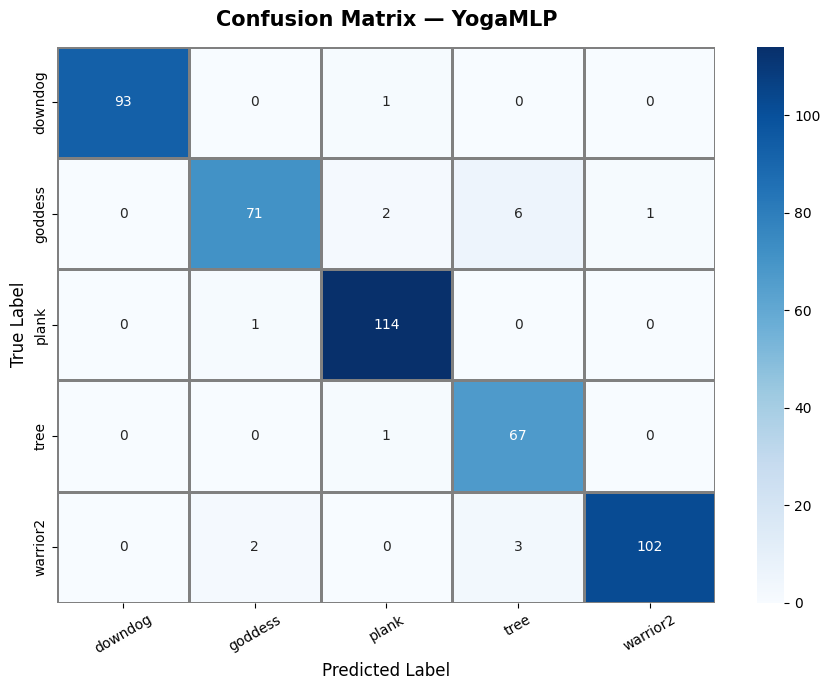

Tất cả file output tại /kaggle/working/


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Load best model
best_model = YogaMLP(input_size=62, num_classes=len(train_ds.label_map)).to(device)
best_model.load_state_dict(torch.load(MODEL_PATH))
best_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        out = best_model(X.to(device))
        _, pred = torch.max(out, 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y.numpy())

idx_to_class = {v: k for k, v in train_ds.label_map.items()}
target_names = [idx_to_class[i] for i in range(num_classes)]

print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(all_labels, all_preds, target_names=target_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=1, linecolor='gray')
plt.title('Confusion Matrix — YogaMLP', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_v2.png', dpi=150)
plt.show()
print("Tất cả file output tại /kaggle/working/")

In [10]:
# ==========================================
# TÓM TẮT CÁC FILE ĐÃ LƯU
# ==========================================
import os

files = [MODEL_PATH, LABEL_MAP_PATH, SCALER_PATH,
         '/kaggle/working/pose_stats.json',
         '/kaggle/working/confusion_matrix_v2.png',
         TRAIN_CSV, TEST_CSV]

print("Output files:")
for fp in files:
    if os.path.exists(fp):
        size = os.path.getsize(fp)
        print(f"  {fp}  ({size/1024:.1f} KB)")
    else:
        print(f"  {fp}  (chưa có)")

Output files:
  /kaggle/working/yoga_best_v2.pth  (239.6 KB)
  /kaggle/working/label_map.json  (0.1 KB)
  /kaggle/working/scaler.pkl  (1.9 KB)
  /kaggle/working/pose_stats.json  (9.6 KB)
  /kaggle/working/confusion_matrix_v2.png  (63.8 KB)
  /kaggle/working/train_v2.csv  (13639.5 KB)
  /kaggle/working/test_v2.csv  (549.6 KB)
